<a href="https://colab.research.google.com/github/Thiyasha0315/harmful-content-detection/blob/thiyasha-dev/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# COLAB RECONNECT CELL (RUN FIRST)
# ============================================

from google.colab import drive
import os

drive.mount('/content/drive')

os.chdir("/content/drive/My Drive/HarmfulContentDetection/harmful-content-detection")
!git status

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Refresh index: 100% (19/19), done.
On branch thiyasha-dev
Your branch is up to date with 'origin/thiyasha-dev'.

nothing to commit, working tree clean


In [ ]:
#Step 2 check if in correct branch and pull from main
!git checkout thiyasha-dev
!git pull origin main

Already on 'thiyasha-dev'
Your branch is up to date with 'origin/thiyasha-dev'.
From https://github.com/Thiyasha0315/harmful-content-detection
 * branch            main       -> FETCH_HEAD
Already up to date.


In [ ]:
#Env check

import torch

if torch.cuda.is_available():
    print("✅ GPU available:", torch.cuda.get_device_name(0))
else:
    print("⚠️ No GPU detected")

import transformers, pandas, numpy
print("✅ Core libraries loaded")

⚠️ No GPU detected
✅ Core libraries loaded


In [ ]:
#all imports
import os
from getpass import getpass
import pandas as pd
import numpy as np
import networkx as nx
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from community import community_louvain
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
os.listdir("data")

['processeddata', 'rawdata', 'README.md']

# Implement The Tables

In [ ]:
print(os.getcwd())

/content/drive/MyDrive/HarmfulContentDetection/harmful-content-detection


In [ ]:
# Load the raw CSVs
posts_raw = pd.read_csv("data/processeddata/Post _Title_Dataset _Sheet1.csv")
comments_raw = pd.read_csv("data/processeddata/Comment_Dataset_dataset_for_annotation.csv", header=None)

# Display what we loaded
print("=" * 80)
print("POSTS RAW DATA")
print("=" * 80)
print(posts_raw.head())
print(f"\nShape: {posts_raw.shape}")
print(f"Columns: {posts_raw.columns.tolist()}")

print("\n" + "=" * 80)
print("COMMENTS RAW DATA")
print("=" * 80)
print(comments_raw.head())
print(f"\nShape: {comments_raw.shape}")
print(f"Columns: {comments_raw.columns.tolist()}")

POSTS RAW DATA
   Video Id                                        Video Title   Label
0         1  ඇමති හඳුන්නෙත්තිගේ හඬපට හුටපටය - මැති සබයත් උණ...  Normal
1         2             බිග් කුච්චන් බිග් කුච්චන්  - Hiru News  Normal
2         3              මම වසන්තට බලු වැඩක් කළා - මට සමාවෙන්න    Hate
3         4      කුඩු වනසන්න අලුත් නීති ගේන්න ජනපතිගෙන් ඉල්ලයි    Hate
4         5  "ශීතකළ එළවළු රටින් ගේන්න ආහාර කමිටුව තීරණය කරල...  Normal

Shape: (5, 3)
Columns: ['Video Id', 'Video Title', 'Label']

COMMENTS RAW DATA
          0                           1                    2  \
0  Video Id                  Comment ID               Author   
1         1  Ugwx_UBFShYeASExmdV4AaABAg   @KrishanDharmasiri   
2         1  UgziEr4CRmhpQ2ZjVXF4AaABAg  @DeepalFernando-k2p   
3         1  UgwdqopqykabZA_I0rN4AaABAg    @gemunugemunu8698   
4         1  UgxXeF6fHtvEIWPExq54AaABAg        @alawagedagoa   

                                                   3      4           5  \
0                  

In [ ]:
# ============================================================================
# STEP 1: Build POSTS table
# ============================================================================

print("\n" + "=" * 80)
print("BUILDING POSTS TABLE")
print("=" * 80)

# Create posts dataframe
posts_df = pd.DataFrame()

# Column mapping from raw data
posts_df['post_id'] = 'yt_video_' + posts_raw['Video Id'].astype(str)
posts_df['platform'] = 'youtube'
posts_df['topic'] = 'politics'  # Hard-coded for now; will vary when you add sports, etc.
posts_df['text'] = posts_raw['Video Title'] # Temporarily create 'text' for mapping
posts_df['label_source'] = 'manual'  # Hard-coded for manual labels
posts_df['label'] = posts_raw['Label']

# Drop the 'text' column as requested by the user
posts_df = posts_df.drop(columns=['text'], errors='ignore')

# Validate: No duplicates
assert posts_df['post_id'].is_unique, "ERROR: Duplicate post_ids found!"
print(f"✓ Unique post_ids: {posts_df['post_id'].is_unique}")

# Validate: No nulls in critical fields (excluding 'text' since it's dropped)
critical_fields = ['post_id', 'platform', 'topic', 'label']
for field in critical_fields:
    nulls = posts_df[field].isnull().sum()
    print(f"✓ Nulls in '{field}': {nulls}")
    assert nulls == 0, f"ERROR: Found {nulls} nulls in '{field}'"

print("\nPOSTS TABLE:")
print(posts_df.to_string())

# Save posts table
posts_df.to_csv('posts_table.csv', index=False)
print("\n✓ Saved to 'posts_table.csv'")


BUILDING POSTS TABLE
✓ Unique post_ids: True
✓ Nulls in 'post_id': 0
✓ Nulls in 'platform': 0
✓ Nulls in 'topic': 0
✓ Nulls in 'label': 0

POSTS TABLE:
      post_id platform     topic label_source   label
0  yt_video_1  youtube  politics       manual  Normal
1  yt_video_2  youtube  politics       manual  Normal
2  yt_video_3  youtube  politics       manual    Hate
3  yt_video_4  youtube  politics       manual    Hate
4  yt_video_5  youtube  politics       manual  Normal

✓ Saved to 'posts_table.csv'


In [ ]:
# ============================================================================
# STEP 2: Parse COMMENTS_RAW into structured columns
# ============================================================================

print("\n" + "=" * 80)
print("PARSING COMMENTS RAW DATA")
print("=" * 80)

# Assign column names (since raw CSV doesn't have headers)
comments_raw.columns = ['video_id', 'comment_id', 'author', 'text', 'likes', 'timestamp', 'clean_text', 'label']

# Remove the actual header row (now at index 0) and reset index
comments_raw = comments_raw[1:].reset_index(drop=True)

print("Comments with assigned columns and header row removed:")
print(comments_raw.head(10))

# Check for data types and issues
print(f"\nData types:\n{comments_raw.dtypes}")
print(f"\nNull counts:\n{comments_raw.isnull().sum()}")

# ============================================================================
# STEP 3: Build USERS table from unique authors in comments
# ============================================================================

print("\n" + "=" * 80)
print("BUILDING USERS TABLE")
print("=" * 80)

# Extract unique users from comments
users_df = pd.DataFrame()

# Clean author names: remove '@' prefix, convert to lowercase
authors = comments_raw['author'].str.replace('@', '', regex=False).str.strip()

# Create user_id: prefix 'yt_user_' + cleaned author
users_df['user_id'] = 'yt_user_' + authors

# Keep only unique users
users_df = users_df.drop_duplicates(subset=['user_id']).reset_index(drop=True)

# Add platform
users_df['platform'] = 'youtube'

# Add created_at and country (optional, NULL for now)
users_df['created_at'] = None
users_df['country'] = None

print(f"Total unique users: {len(users_df)}")
print("\nUSERS TABLE (first 10):")
print(users_df.head(10).to_string())

# Validate
assert users_df['user_id'].is_unique, "ERROR: Duplicate user_ids!"
print(f"\n✓ Unique user_ids: {users_df['user_id'].is_unique}")

# Save users table
users_df.to_csv('users_table.csv', index=False)
print("✓ Saved to 'users_table.csv'")


PARSING COMMENTS RAW DATA
Comments with assigned columns and header row removed:
  video_id                  comment_id                     author  \
0        1  Ugwx_UBFShYeASExmdV4AaABAg         @KrishanDharmasiri   
1        1  UgziEr4CRmhpQ2ZjVXF4AaABAg        @DeepalFernando-k2p   
2        1  UgwdqopqykabZA_I0rN4AaABAg          @gemunugemunu8698   
3        1  UgxXeF6fHtvEIWPExq54AaABAg              @alawagedagoa   
4        1  UgygXeXvB1BimoBrc254AaABAg  @kithsirigeethakumara8533   
5        1  UgwPY660tLHxRFv1OBl4AaABAg      @LeelasiriEdirisingha   
6        1  UgyVo4BcH7pB_eK8WP14AaABAg             @padhmalpeiris   
7        1  UgwTB4ll3biDwmD7sVl4AaABAg                 @syndi-w3k   
8        1  Ugwn3dikAK3ob48rqZx4AaABAg            @ChammiWasantha   
9        1  UgybZEIg6GlkFb8EIwt4AaABAg          @TharinduKodagoda   

                                                text likes   timestamp  \
0  හදුහේටියා මඩකලපුමිල්ලා හේලි කොප්පරේන්ගිහිල...     0  1764720000   
1         

In [ ]:
# ============================================================================
# STEP 4: Build INTERACTIONS table
# ============================================================================

print("\n" + "=" * 80)
print("BUILDING INTERACTIONS TABLE")
print("=" * 80)

interactions_df = pd.DataFrame()

# Auto-increment interaction_id (1, 2, 3, ...)
# comments_raw is now already cleaned and indexed from 0 after running the previous cell
interactions_df['interaction_id'] = range(1, len(comments_raw) + 1)

# Direct mappings from raw comments (no need for [1:] anymore)
interactions_df['comment_id'] = comments_raw['comment_id'].astype(str)
interactions_df['text'] = comments_raw['text']
interactions_df['clean_text'] = comments_raw['clean_text']
interactions_df['likes_count'] = comments_raw['likes'].astype(int)

# Convert timestamp to integer (Unix seconds)
interactions_df['timestamp'] = comments_raw['timestamp'].astype(int)

# Create user_id (clean author + prefix)
interactions_df['user_id'] = 'yt_user_' + comments_raw['author'].str.replace('@', '', regex=False).str.strip()

# Create post_id from video_id
interactions_df['post_id'] = 'yt_video_' + comments_raw['video_id'].astype(str)

# Fixed fields
interactions_df['interaction_type'] = 'comment'  # All are comments in this dataset
interactions_df['platform'] = 'youtube'
interactions_df['topic'] = 'politics'

# Label source and label (with cleaning)
interactions_df['label_source'] = 'manual'
interactions_df['label'] = comments_raw['label'].str.strip()  # Remove any whitespace/\r\n
# Drop the 'text' and 'clean_text' columns as requested
interactions_df = interactions_df.drop(columns=['text', 'clean_text'], errors='ignore')

print(f"Total interactions: {len(interactions_df)}")
print("\nINTERACTIONS TABLE (first 10):")
print(interactions_df.head(10).to_string())

# Validate
print("\n" + "-" * 80)
print("VALIDATION CHECKS")
print("-" * 80)

# Check 1: interaction_id is unique and sequential
assert interactions_df['interaction_id'].is_unique, "ERROR: Duplicate interaction_ids!"
assert list(interactions_df['interaction_id']) == list(range(1, len(interactions_df) + 1)), "ERROR: interaction_id not sequential!"
print(f"✓ interaction_id: unique and sequential (1 to {len(interactions_df)})")

# Check 2: comment_id is unique
assert interactions_df['comment_id'].is_unique, "ERROR: Duplicate comment_ids!"
print(f"✓ comment_id: all unique")

# Check 3: All user_ids exist in users table
invalid_users = ~interactions_df['user_id'].isin(users_df['user_id'])
if invalid_users.any():
    print(f"⚠ WARNING: {invalid_users.sum()} interactions have unknown user_ids")
else:
    print(f"✓ user_id: all references exist in users table")

# Check 4: All post_ids exist in posts table
invalid_posts = ~interactions_df['post_id'].isin(posts_df['post_id'])
if invalid_posts.any():
    print(f"⚠ WARNING: {invalid_posts.sum()} interactions have unknown post_ids")
else:
    print(f"✓ post_id: all references exist in posts table")

# Check 5: No nulls in critical fields
critical_interaction_fields = ['interaction_id', 'comment_id', 'user_id', 'post_id', 'timestamp', 'label']
for field in critical_interaction_fields:
    nulls = interactions_df[field].isnull().sum()
    print(f"✓ Nulls in '{field}': {nulls}")
    assert nulls == 0, f"ERROR: Found {nulls} nulls in '{field}'"

# Check 6: Label values are valid
valid_labels = {'Normal', 'Hate', 'Disinfo'}
actual_labels = set(interactions_df['label'].unique())
print(f"✓ Label values: {actual_labels}")

# Save interactions table
interactions_df.to_csv('interactions_table.csv', index=False)
print("\n✓ Saved to 'interactions_table.csv'")


BUILDING INTERACTIONS TABLE
Total interactions: 516

INTERACTIONS TABLE (first 10):
   interaction_id                  comment_id  likes_count   timestamp                           user_id     post_id interaction_type platform     topic label_source    label
0               1  Ugwx_UBFShYeASExmdV4AaABAg            0  1764720000         yt_user_KrishanDharmasiri  yt_video_1          comment  youtube  politics       manual  Disinfo
1               2  UgziEr4CRmhpQ2ZjVXF4AaABAg            0  1764547200        yt_user_DeepalFernando-k2p  yt_video_1          comment  youtube  politics       manual     Hate
2               3  UgwdqopqykabZA_I0rN4AaABAg            0  1764460800          yt_user_gemunugemunu8698  yt_video_1          comment  youtube  politics       manual   Normal
3               4  UgxXeF6fHtvEIWPExq54AaABAg            1  1764460800              yt_user_alawagedagoa  yt_video_1          comment  youtube  politics       manual   Normal
4               5  UgygXeXvB1BimoBrc254A

# Graph Construction

In [ ]:
posts_df = pd.read_csv('posts_table.csv')
users_df = pd.read_csv('users_table.csv')
interactions_df = pd.read_csv('interactions_table.csv')

In [ ]:
# Create an empty Graph
G_bipartite = nx.Graph()

# 1) Add USER nodes
for _, row in users_df.iterrows():
    G_bipartite.add_node(
        row['user_id'],
        node_type='user',       # so you can distinguish user vs post
        platform=row['platform']
    )

# 2) Add POST nodes
for _, row in posts_df.iterrows():
    G_bipartite.add_node(
        row['post_id'],
        node_type='post',
        label=row['label'],     # Normal / Hate / Disinfo at post level
        topic=row['topic'],
        platform=row['platform']
    )

# 3) Add EDGES between user and post for each interaction (comment)
for _, row in interactions_df.iterrows():
    G_bipartite.add_edge(
        row['user_id'],
        row['post_id'],
        likes=row['likes_count'],
        timestamp=row['timestamp'],
        interaction_type=row['interaction_type'],  # here always 'comment'
        label=row['label']      # label of the comment itself
    )

In [ ]:
#Sanity Checks
print("Total nodes:", G_bipartite.number_of_nodes())
print("Total edges:", G_bipartite.number_of_edges())

user_nodes = [n for n, d in G_bipartite.nodes(data=True) if d.get('node_type') == 'user']
post_nodes = [n for n, d in G_bipartite.nodes(data=True) if d.get('node_type') == 'post']

print("User nodes:", len(user_nodes))
print("Post nodes:", len(post_nodes))

print("Is bipartite?", nx.is_bipartite(G_bipartite))

Total nodes: 444
Total edges: 447
User nodes: 439
Post nodes: 5
Is bipartite? True


In [ ]:
#Project to full user–user graph
# Initialize empty user-user graph
G_full = nx.Graph()

# Add user nodes
for u in user_nodes:
    G_full.add_node(u)

# For each post, connect all pairs of users who commented on it
for post in post_nodes:
    # users connected to this post in bipartite graph
    users_on_post = [n for n in G_bipartite.neighbors(post)
                     if G_bipartite.nodes[n].get('node_type') == 'user']
    if len(users_on_post) < 2:
        continue

    # For each pair of users, add/accumulate an edge
    for i in range(len(users_on_post)):
        for j in range(i+1, len(users_on_post)):
            u1 = users_on_post[i]
            u2 = users_on_post[j]

            if G_full.has_edge(u1, u2):
                G_full[u1][u2]['shared_posts'] += 1
            else:
                G_full.add_edge(u1, u2, shared_posts=1)

In [ ]:
#Check Stats
print("G_full nodes:", G_full.number_of_nodes())
print("G_full edges:", G_full.number_of_edges())
print("G_full density:", nx.density(G_full))

print("Is connected?", nx.is_connected(G_full))
if not nx.is_connected(G_full):
    print("Connected components:", nx.number_connected_components(G_full))

G_full nodes: 439
G_full edges: 30310
G_full density: 0.31526611955357237
Is connected? True


In [ ]:
#Clean label typos
interactions_df['label'] = interactions_df['label'].replace({
    'Disnfo': 'Disinfo',
    'Nomal': 'Normal'
})

In [ ]:
#Filter disinfo and hate interactions
hate_interactions = interactions_df[interactions_df['label'] == 'Hate'].copy()
disinfo_interactions = interactions_df[interactions_df['label'] == 'Disinfo'].copy()

print("Hate interactions:", len(hate_interactions))
print("Disinfo interactions:", len(disinfo_interactions))

Hate interactions: 167
Disinfo interactions: 8


In [ ]:
#Build disinfo bipartite graph
def build_user_user_from_interactions(sub_interactions, users_df, posts_df, edge_attr_name):
    """
    sub_interactions: DataFrame with columns user_id, post_id
    edge_attr_name: 'shared_hate_posts' or 'shared_disinfo_posts'
    """
    # Build bipartite for this subset
    G_bip = nx.Graph()

    # User nodes
    for _, row in users_df.iterrows():
        G_bip.add_node(row['user_id'], node_type='user')

    # Post nodes
    for _, row in posts_df.iterrows():
        G_bip.add_node(row['post_id'], node_type='post')

    # Edges: only from this subset
    for _, row in sub_interactions.iterrows():
        G_bip.add_edge(row['user_id'], row['post_id'])

    # Project to user-user
    G_uu = nx.Graph()
    for u in users_df['user_id']:
        G_uu.add_node(u)

    post_nodes_local = [n for n, d in G_bip.nodes(data=True) if d['node_type'] == 'post']

    for post in post_nodes_local:
        users_on_post = [n for n in G_bip.neighbors(post)
                         if G_bip.nodes[n]['node_type'] == 'user']
        if len(users_on_post) < 2:
            continue

        for i in range(len(users_on_post)):
            for j in range(i+1, len(users_on_post)):
                u1 = users_on_post[i]
                u2 = users_on_post[j]
                if G_uu.has_edge(u1, u2):
                    G_uu[u1][u2][edge_attr_name] += 1
                else:
                    G_uu.add_edge(u1, u2, **{edge_attr_name: 1})
    return G_uu

In [ ]:
G_hate = build_user_user_from_interactions(
    hate_interactions,
    users_df,
    posts_df,
    edge_attr_name='shared_hate_posts'
)

G_disinfo = build_user_user_from_interactions(
    disinfo_interactions,
    users_df,
    posts_df,
    edge_attr_name='shared_disinfo_posts'
)

print("G_hate:")
print("  nodes:", G_hate.number_of_nodes())
print("  edges:", G_hate.number_of_edges())
print("  density:", nx.density(G_hate))

print("G_disinfo:")
print("  nodes:", G_disinfo.number_of_nodes())
print("  edges:", G_disinfo.number_of_edges())
print("  density:", nx.density(G_disinfo))

active_hate_users = sum(1 for n in G_hate.nodes() if G_hate.degree(n) > 0)
active_disinfo_users = sum(1 for n in G_disinfo.nodes() if G_disinfo.degree(n) > 0)

print("Active hate users (deg>0):", active_hate_users)
print("Active disinfo users (deg>0):", active_disinfo_users)

G_hate:
  nodes: 439
  edges: 3460
  density: 0.0359888081047628
G_disinfo:
  nodes: 439
  edges: 9
  density: 9.361250663088588e-05
Active hate users (deg>0): 142
Active disinfo users (deg>0): 7


In [ ]:
#Quick degree statistics

# Full graph degrees
deg_full = [G_full.degree(n) for n in G_full.nodes()]
print("Full graph degree: min", np.min(deg_full),
      "max", np.max(deg_full),
      "mean", np.mean(deg_full),
      "median", np.median(deg_full))

# Disinfo graph degrees (only active)
deg_dis = [G_disinfo.degree(n) for n in G_disinfo.nodes() if G_disinfo.degree(n) > 0]
print("Disinfo graph degree (active users): min", np.min(deg_dis),
      "max", np.max(deg_dis),
      "mean", np.mean(deg_dis),
      "median", np.median(deg_dis))

Full graph degree: min 2 max 319 mean 138.0865603644647 median 153.0
Disinfo graph degree (active users): min 2 max 3 mean 2.5714285714285716 median 3.0


Testing a user and neighbours in full graph and disinfo graph

In [ ]:
# Example: pick the first user_id from users_df
sample_user = users_df['user_id'].iloc[0]
print("Sample user:", sample_user)

Sample user: yt_user_KrishanDharmasiri


In [ ]:
# Neighbors in full graph
neighbors_full = list(G_full.neighbors(sample_user))
print("\nNeighbors in FULL graph (count:", len(neighbors_full), "):")
print(neighbors_full[:20])  # show first 20 for brevity

# Neighbors in disinfo graph
neighbors_disinfo = list(G_disinfo.neighbors(sample_user))
print("\nNeighbors in DISINFO graph (count:", len(neighbors_disinfo), "):")
print(neighbors_disinfo[:20])


Neighbors in FULL graph (count: 31 ):
['yt_user_DeepalFernando-k2p', 'yt_user_gemunugemunu8698', 'yt_user_alawagedagoa', 'yt_user_kithsirigeethakumara8533', 'yt_user_LeelasiriEdirisingha', 'yt_user_padhmalpeiris', 'yt_user_syndi-w3k', 'yt_user_ChammiWasantha', 'yt_user_TharinduKodagoda', 'yt_user_ashokaherath783', 'yt_user_ගමගාල්ල', 'yt_user_TheConcepts-සංකල්ප-l8v', 'yt_user_LaSLMax', 'yt_user_ධර්මතුංගදිසානායක', 'yt_user_katsullivan', 'yt_user_NethmiNisansala-v3i7i', 'yt_user_gayanhettiarachchi-q2k', 'yt_user_avenom3877', 'yt_user_hashmilasewwandi9118', 'yt_user_ilovenaturevibe']

Neighbors in DISINFO graph (count: 3 ):
['yt_user_syndi-w3k', 'yt_user_ChammiWasantha', 'yt_user_ගමගාල්ල']


In [ ]:
print("\nFull graph edges for sample user (first 10):")
for nbr in neighbors_full[:10]:
    data = G_full[sample_user][nbr]
    print(sample_user, "<->", nbr, "| shared_posts:", data.get('shared_posts'))

print("\nDisinfo graph edges for sample user (first 10):")
for nbr in neighbors_disinfo[:10]:
    data = G_disinfo[sample_user][nbr]
    print(sample_user, "<->", nbr, "| shared_disinfo_posts:", data.get('shared_disinfo_posts'))


Full graph edges for sample user (first 10):
yt_user_KrishanDharmasiri <-> yt_user_DeepalFernando-k2p | shared_posts: 1
yt_user_KrishanDharmasiri <-> yt_user_gemunugemunu8698 | shared_posts: 1
yt_user_KrishanDharmasiri <-> yt_user_alawagedagoa | shared_posts: 1
yt_user_KrishanDharmasiri <-> yt_user_kithsirigeethakumara8533 | shared_posts: 1
yt_user_KrishanDharmasiri <-> yt_user_LeelasiriEdirisingha | shared_posts: 1
yt_user_KrishanDharmasiri <-> yt_user_padhmalpeiris | shared_posts: 1
yt_user_KrishanDharmasiri <-> yt_user_syndi-w3k | shared_posts: 1
yt_user_KrishanDharmasiri <-> yt_user_ChammiWasantha | shared_posts: 1
yt_user_KrishanDharmasiri <-> yt_user_TharinduKodagoda | shared_posts: 1
yt_user_KrishanDharmasiri <-> yt_user_ashokaherath783 | shared_posts: 1

Disinfo graph edges for sample user (first 10):
yt_user_KrishanDharmasiri <-> yt_user_syndi-w3k | shared_disinfo_posts: 1
yt_user_KrishanDharmasiri <-> yt_user_ChammiWasantha | shared_disinfo_posts: 1
yt_user_KrishanDharmasiri

# Centrality & Influence Metrics.

In [ ]:
# Centralities
deg_centrality = nx.degree_centrality(G_full)
bet_centrality = nx.betweenness_centrality(G_full, normalized=True)
clo_centrality = nx.closeness_centrality(G_full)
pagerank = nx.pagerank(G_full, alpha=0.85)

# Build influence_df
influence_df = pd.DataFrame({'user_id': list(G_full.nodes())}).set_index('user_id')
influence_df['degree_centrality'] = influence_df.index.map(deg_centrality.get)
influence_df['betweenness_centrality'] = influence_df.index.map(bet_centrality.get)
influence_df['closeness_centrality'] = influence_df.index.map(clo_centrality.get)
influence_df['pagerank'] = influence_df.index.map(pagerank.get)

# Normalize centralities
scaler = MinMaxScaler()
cent_cols = ['degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'pagerank']
influence_df[cent_cols] = scaler.fit_transform(influence_df[cent_cols])

In [ ]:
# Total interactions
user_total = interactions_df.groupby('user_id').size().rename('total_interactions')

# Hate / Disinfo counts
user_hate = interactions_df[interactions_df['label'] == 'Hate'].groupby('user_id').size().rename('hate_interactions')
user_disinfo = interactions_df[interactions_df['label'] == 'Disinfo'].groupby('user_id').size().rename('disinfo_interactions')

engagement_df = pd.concat([user_total, user_hate, user_disinfo], axis=1).fillna(0)
engagement_df['hate_ratio'] = engagement_df['hate_interactions'] / engagement_df['total_interactions']
engagement_df['disinfo_ratio'] = engagement_df['disinfo_interactions'] / engagement_df['total_interactions']
engagement_df['harmful_ratio'] = (engagement_df['hate_interactions'] + engagement_df['disinfo_interactions']) / engagement_df['total_interactions']

# Optionally scale total_interactions too (for later use)
engagement_df['total_interactions_scaled'] = scaler.fit_transform(engagement_df[['total_interactions']])

# Join into influence_df
influence_df = influence_df.join(engagement_df, how='left').fillna(0)

Inspection of top users

In [ ]:
# Sort by pagerank
top_by_pagerank = influence_df.sort_values('pagerank', ascending=False).head(10)
print("\nTop 10 by PageRank:")
print(top_by_pagerank[['pagerank', 'degree_centrality', 'disinfo_ratio']])

# Sort by disinfo_ratio (only users with at least few interactions)
top_by_disinfo = influence_df.sort_values('disinfo_ratio', ascending=False).head(10)
print("\nTop 10 by disinfo_ratio (min 4 interactions):")
print(top_by_disinfo[['disinfo_ratio', 'total_interactions', 'pagerank']])


Top 10 by PageRank:
                                     pagerank  degree_centrality  \
user_id                                                            
yt_user_skg9581                      1.000000           1.000000   
yt_user_rajithavroon9938             1.000000           1.000000   
yt_user_nimaljayasiri6065            0.983304           0.798107   
yt_user_freedomis8551                0.983304           0.798107   
yt_user_kasunmalinga3412             0.856357           0.615142   
yt_user_LeelasiriEdirisingha         0.856357           0.615142   
yt_user_padhmalpeiris                0.822169           0.372240   
yt_user_Krishna-kd3ns                0.597211           0.482650   
yt_user_WasanthaSamarawikrama-v9w4j  0.472652           0.520505   
yt_user_ChinthanaJayathilaka-wx9jb   0.472652           0.520505   

                                     disinfo_ratio  
user_id                                             
yt_user_skg9581                                0.0  
yt_

Composite Risk Score


In [ ]:
# Risk score: influence + harmful engagement
influence_df['risk_score'] = (
    0.5 * influence_df['pagerank'] +
    0.3 * influence_df['degree_centrality'] +
    0.2 * influence_df['harmful_ratio']
)

# Inspect top users
top_risk = influence_df.sort_values('risk_score', ascending=False).head(20)
print(top_risk[['pagerank', 'hate_ratio', 'disinfo_ratio', 'harmful_ratio', 'risk_score']])

                                      pagerank  hate_ratio  disinfo_ratio  \
user_id                                                                     
yt_user_skg9581                       1.000000    0.666667            0.0   
yt_user_rajithavroon9938              1.000000    0.500000            0.0   
yt_user_nimaljayasiri6065             0.983304    0.666667            0.0   
yt_user_freedomis8551                 0.983304    0.500000            0.0   
yt_user_kasunmalinga3412              0.856357    0.500000            0.0   
yt_user_padhmalpeiris                 0.822169    0.500000            0.0   
yt_user_LeelasiriEdirisingha          0.856357    0.000000            0.0   
yt_user_subhashiranathunga3055        0.472652    1.000000            0.0   
yt_user_dorawakarev.wimala2508        0.472652    1.000000            0.0   
yt_user_SameeraSandaruwan-el3jv       0.472652    1.000000            0.0   
yt_user_Sanjeewasampath-j9b           0.472652    1.000000            0.0   

# Community Detection

In [ ]:
# Detect communities on full graph
communities_dict = community_louvain.best_partition(G_full)

print("Communities detected:", len(set(communities_dict.values())))
print("Sample:", list(communities_dict.items())[:10])

Communities detected: 4
Sample: [('yt_user_KrishanDharmasiri', 0), ('yt_user_DeepalFernando-k2p', 0), ('yt_user_gemunugemunu8698', 0), ('yt_user_alawagedagoa', 0), ('yt_user_kithsirigeethakumara8533', 0), ('yt_user_LeelasiriEdirisingha', 1), ('yt_user_padhmalpeiris', 2), ('yt_user_syndi-w3k', 0), ('yt_user_ChammiWasantha', 0), ('yt_user_TharinduKodagoda', 0)]


In [ ]:
# communities_dict: {user_id: community_id}
influence_df['community_id'] = influence_df.index.map(communities_dict.get)

In [ ]:
print(influence_df.head())
print(influence_df.columns)

                                  degree_centrality  betweenness_centrality  \
user_id                                                                       
yt_user_KrishanDharmasiri                  0.091483                     0.0   
yt_user_DeepalFernando-k2p                 0.091483                     0.0   
yt_user_gemunugemunu8698                   0.091483                     0.0   
yt_user_alawagedagoa                       0.091483                     0.0   
yt_user_kithsirigeethakumara8533           0.091483                     0.0   

                                  closeness_centrality  pagerank  \
user_id                                                            
yt_user_KrishanDharmasiri                     0.211868  0.304298   
yt_user_DeepalFernando-k2p                    0.211868  0.304298   
yt_user_gemunugemunu8698                      0.211868  0.304298   
yt_user_alawagedagoa                          0.211868  0.304298   
yt_user_kithsirigeethakumara8533      

In [ ]:
# Add community assignment to influence_df
influence_df['community_id'] = influence_df.index.map(communities_dict.get)
tmp = influence_df.reset_index()  # brings user_id out as a column

# Group by community
community_summary = tmp.groupby('community_id').agg({
    'user_id': 'count',                           # num users in community
    'pagerank': 'mean',                           # avg influence
    'hate_ratio': 'mean',                         # avg hate engagement
    'disinfo_ratio': 'mean',                      # avg disinfo engagement
    'harmful_ratio': 'mean',                      # combined harmful avg
    'total_interactions': 'sum'                   # total interactions in community
}).rename(columns={'user_id': 'community_size'})

# Also: what fraction of interactions in this community are hate/disinfo?
community_summary['hate_concentration'] = 0.0
community_summary['disinfo_concentration'] = 0.0

for comm_id in community_summary.index:
    # users in this community
    if 'user_id' in tmp.columns:
        users_in_comm = tmp[tmp['community_id'] == comm_id]['user_id']
    else:
        users_in_comm = influence_df[influence_df['community_id'] == comm_id].index

    comm_interactions = interactions_df[interactions_df['user_id'].isin(users_in_comm)]

    if len(comm_interactions) > 0:
        hate_count = (comm_interactions['label'] == 'Hate').sum()
        disinfo_count = (comm_interactions['label'] == 'Disinfo').sum()
        community_summary.loc[comm_id, 'hate_concentration'] = hate_count / len(comm_interactions)
        community_summary.loc[comm_id, 'disinfo_concentration'] = disinfo_count / len(comm_interactions)

# Sort by harmful ratio
community_summary = community_summary.sort_values('harmful_ratio', ascending=False)

print(community_summary)

              community_size  pagerank  hate_ratio  disinfo_ratio  \
community_id                                                        
2                         90  0.453146    0.628148       0.000000   
0                         29  0.304298    0.344828       0.120690   
1                        164  0.477331    0.306911       0.018293   
3                        156  0.455674    0.092094       0.006410   

              harmful_ratio  total_interactions  hate_concentration  \
community_id                                                          
2                  0.628148                 128            0.601562   
0                  0.465517                  32            0.375000   
1                  0.325203                 179            0.318436   
3                  0.098504                 177            0.118644   

              disinfo_concentration  
community_id                         
2                           0.00000  
0                           0.12500  
1     

In [ ]:
#Assign Community type Labels
def classify_community(row):
    hate_conc = row['hate_concentration']
    disinfo_conc = row['disinfo_concentration']
    harmful = row['harmful_ratio']

    if harmful < 0.1:
        return 'Normal / Low Harm'
    elif hate_conc > disinfo_conc and hate_conc > 0.3:
        return 'Hate Echo Chamber'
    elif disinfo_conc > hate_conc and disinfo_conc > 0.2:
        return 'Disinformation Hub'
    elif harmful > 0.25:
        return 'Mixed Harmful'
    else:
        return 'Low/Medium Harm'

community_summary['community_type'] = community_summary.apply(classify_community, axis=1)

print(community_summary[['community_size','harmful_ratio','hate_concentration','disinfo_concentration','community_type']])

              community_size  harmful_ratio  hate_concentration  \
community_id                                                      
2                         90       0.628148            0.601562   
0                         29       0.465517            0.375000   
1                        164       0.325203            0.318436   
3                        156       0.098504            0.118644   

              disinfo_concentration     community_type  
community_id                                            
2                           0.00000  Hate Echo Chamber  
0                           0.12500  Hate Echo Chamber  
1                           0.01676  Hate Echo Chamber  
3                           0.00565  Normal / Low Harm  


In [ ]:
# Map community_type into influence_df (user-level)
influence_df['community_type'] = influence_df['community_id'].map(
    community_summary['community_type']
)

# See top-risk users with community labels
top_risk_users = influence_df.sort_values('risk_score', ascending=False).head(20)
print(top_risk_users[['risk_score','hate_ratio','disinfo_ratio','community_id','community_type']])

                                      risk_score  hate_ratio  disinfo_ratio  \
user_id                                                                       
yt_user_skg9581                         0.933333    0.666667            0.0   
yt_user_rajithavroon9938                0.900000    0.500000            0.0   
yt_user_nimaljayasiri6065               0.864417    0.666667            0.0   
yt_user_freedomis8551                   0.831084    0.500000            0.0   
yt_user_kasunmalinga3412                0.712721    0.500000            0.0   
yt_user_padhmalpeiris                   0.622757    0.500000            0.0   
yt_user_LeelasiriEdirisingha            0.612721    0.000000            0.0   
yt_user_subhashiranathunga3055          0.592477    1.000000            0.0   
yt_user_dorawakarev.wimala2508          0.592477    1.000000            0.0   
yt_user_SameeraSandaruwan-el3jv         0.592477    1.000000            0.0   
yt_user_Sanjeewasampath-j9b             0.592477    

# Active Learning

In [ ]:
# 1. Define Ground Truth Label (y)
# We use the data we have to simulate "truth"
influence_df['is_high_risk'] = (influence_df['harmful_ratio'] > 0.3).astype(int)

print("Class balance:")
print(influence_df['is_high_risk'].value_counts())

# 2. Define Features (X)
# WE CANNOT USE: hate_ratio, disinfo_ratio, harmful_ratio, risk_score (these reveal the answer)
# WE CAN USE: Centrality, Total Interactions, Community ID
feature_cols = [
    'degree_centrality',
    'betweenness_centrality',
    'closeness_centrality',
    'pagerank',
    'total_interactions',
    'community_id'
]

X = influence_df[feature_cols].copy()
y = influence_df['is_high_risk'].copy()

# Fill any NaNs just in case
X = X.fillna(0)

Class balance:
is_high_risk
0    291
1    148
Name: count, dtype: int64


In [ ]:
# Initial Split
X_seed, X_pool, y_seed, y_pool = train_test_split(
    X, y, test_size=0.90, random_state=42, stratify=y
)

print(f"Seed set size: {len(X_seed)}")
print(f"Pool set size: {len(X_pool)}")

Seed set size: 43
Pool set size: 396


In [ ]:
# Initialize model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train on seed
rf_model.fit(X_seed, y_seed)

# Predict on Pool (just to see how bad it is initially)
y_pred_pool = rf_model.predict(X_pool)
print(f"Initial F1 Score on Pool: {f1_score(y_pool, y_pred_pool):.3f}")

Initial F1 Score on Pool: 0.560


Selection Stratergy - Uncertainty + Influence

In [ ]:
def select_next_batch(model, X_pool, pool_indices, n_instances=10):
    """
    Selects top n_instances from X_pool to annotate next.
    Strategy: Entropy (Uncertainty) weighted by PageRank (Influence).
    """
    # 1. Get probability predictions
    probs = model.predict_proba(X_pool)[:, 1] # Probability of being High Risk (1)

    # 2. Calculate Uncertainty (Entropy)
    # Formula: -p*log(p) - (1-p)*log(1-p)
    # Simple proxy: 1 - |p - 0.5|*2  (0 at edges, 1 at 0.5)
    uncertainty = 1 - np.abs(probs - 0.5) * 2

    # 3. Get Influence (PageRank)
    # We need to pull pagerank from the original X_pool dataframe
    influence = X_pool['pagerank'].values

    # 4. Calculate Selection Score
    selection_score = uncertainty * influence

    # 5. Pick Top N indices
    # We return the indices of the rows with highest scores
    top_indices_local = np.argsort(selection_score)[-n_instances:]
    top_indices_global = pool_indices[top_indices_local]

    return top_indices_global

# Prepare indices for simulation
pool_indices = X_pool.index.to_numpy()
seed_indices = X_seed.index.to_numpy()

In [ ]:
current_X_train = X_seed.copy()
current_y_train = y_seed.copy()
current_X_pool = X_pool.copy()
current_y_pool = y_pool.copy()

print("\n--- Starting Active Learning Loop ---")

for round_i in range(1, 6): # 5 rounds
    # 1. Train Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(current_X_train, current_y_train)

    # Evaluate current performance on the remaining pool (truth)
    y_pool_pred = model.predict(current_X_pool)
    current_f1 = f1_score(current_y_pool, y_pool_pred, zero_division=0)
    print(f"Round {round_i}: Training Size = {len(current_X_train)}, Pool F1 Score = {current_f1:.3f}")

    # 2. Select next batch
    # We need the pool indices to know who to move
    pool_index_list = current_X_pool.index.to_numpy()

    selected_indices = select_next_batch(model, current_X_pool, pool_index_list, n_instances=10)

    # 3. "Annotate" (Move from Pool to Train)
    # Get features and labels for selected users
    new_X = current_X_pool.loc[selected_indices]
    new_y = current_y_pool.loc[selected_indices]

    # Add to Train
    current_X_train = pd.concat([current_X_train, new_X])
    current_y_train = pd.concat([current_y_train, new_y])

    # Remove from Pool
    current_X_pool = current_X_pool.drop(selected_indices)
    current_y_pool = current_y_pool.drop(selected_indices)

print("--- Loop Complete ---")


--- Starting Active Learning Loop ---
Round 1: Training Size = 43, Pool F1 Score = 0.560
Round 2: Training Size = 53, Pool F1 Score = 0.541
Round 3: Training Size = 63, Pool F1 Score = 0.540
Round 4: Training Size = 73, Pool F1 Score = 0.525
Round 5: Training Size = 83, Pool F1 Score = 0.536
--- Loop Complete ---


# Content Based Features

In [ ]:
def get_user_explanation(target_user_id, graph, risk_df):
    """
    Returns a dataframe of the target user's neighbors,
    sorted by their influence (PageRank), showing their risk levels.
    """
    if target_user_id not in graph:
        return None

    # Get neighbors
    neighbors = list(graph.neighbors(target_user_id))

    # Get their stats from risk_df
    # We want: pagerank, harmful_ratio, community_type
    nbr_stats = risk_df.loc[neighbors, ['pagerank', 'harmful_ratio', 'community_type']].copy()

    # Sort neighbors by Influence (PageRank) -> "Who is the biggest influencer on this user?"
    nbr_stats = nbr_stats.sort_values('pagerank', ascending=False).head(5)

    return nbr_stats

# Example: Pick the highest risk user from Step 3
top_risk_user = top_risk.index[0]
print(f"--- Why is {top_risk_user} High Risk? ---")
print(f"Community: {influence_df.loc[top_risk_user, 'community_type']}")
print(f"Harmful Ratio: {influence_df.loc[top_risk_user, 'harmful_ratio']:.2f}")

print("\nTop 5 Influential Neighbors:")
explanation = get_user_explanation(top_risk_user, G_full, influence_df)
print(explanation)

--- Why is yt_user_skg9581 High Risk? ---
Community: Normal / Low Harm
Harmful Ratio: 0.67

Top 5 Influential Neighbors:
                              pagerank  harmful_ratio     community_type
user_id                                                                 
yt_user_rajithavroon9938      1.000000       0.500000  Normal / Low Harm
yt_user_nimaljayasiri6065     0.983304       0.666667  Hate Echo Chamber
yt_user_freedomis8551         0.983304       0.500000  Hate Echo Chamber
yt_user_LeelasiriEdirisingha  0.856357       0.000000  Hate Echo Chamber
yt_user_kasunmalinga3412      0.856357       0.500000  Hate Echo Chamber


# Outputs


In [ ]:
user_risk_df = influence_df[[
    'degree_centrality',
    'betweenness_centrality',
    'closeness_centrality',
    'pagerank',
    'total_interactions',
    'hate_interactions',
    'disinfo_interactions',
    'hate_ratio',
    'disinfo_ratio',
    'harmful_ratio',
    'community_id',
    'community_type',
    'risk_score'
]].copy()

user_risk_df = user_risk_df.sort_values('risk_score', ascending=False)
print(user_risk_df.head(20))

                                      degree_centrality  \
user_id                                                   
yt_user_skg9581                                1.000000   
yt_user_rajithavroon9938                       1.000000   
yt_user_nimaljayasiri6065                      0.798107   
yt_user_freedomis8551                          0.798107   
yt_user_kasunmalinga3412                       0.615142   
yt_user_padhmalpeiris                          0.372240   
yt_user_LeelasiriEdirisingha                   0.615142   
yt_user_subhashiranathunga3055                 0.520505   
yt_user_dorawakarev.wimala2508                 0.520505   
yt_user_SameeraSandaruwan-el3jv                0.520505   
yt_user_Sanjeewasampath-j9b                    0.520505   
yt_user_ajithkumara2401                        0.520505   
yt_user_wijethungachaminda7999                 0.520505   
yt_user_GayanKuamra                            0.520505   
yt_user_AmilaEresh-t1r                         0.520505 

In [ ]:
def risk_tier(score):
    if score >= 0.7:
        return 'High'
    elif score >= 0.4:
        return 'Medium'
    else:
        return 'Low'

user_risk_df['risk_tier'] = user_risk_df['risk_score'].apply(risk_tier)

print(user_risk_df['risk_tier'].value_counts())
print(user_risk_df.head(20)[['risk_score','risk_tier','community_type']])

risk_tier
Low       305
Medium    129
High        5
Name: count, dtype: int64
                                      risk_score risk_tier     community_type
user_id                                                                      
yt_user_skg9581                         0.933333      High  Normal / Low Harm
yt_user_rajithavroon9938                0.900000      High  Normal / Low Harm
yt_user_nimaljayasiri6065               0.864417      High  Hate Echo Chamber
yt_user_freedomis8551                   0.831084      High  Hate Echo Chamber
yt_user_kasunmalinga3412                0.712721      High  Hate Echo Chamber
yt_user_padhmalpeiris                   0.622757    Medium  Hate Echo Chamber
yt_user_LeelasiriEdirisingha            0.612721    Medium  Hate Echo Chamber
yt_user_subhashiranathunga3055          0.592477    Medium  Hate Echo Chamber
yt_user_dorawakarev.wimala2508          0.592477    Medium  Hate Echo Chamber
yt_user_SameeraSandaruwan-el3jv         0.592477    Medium  Hate

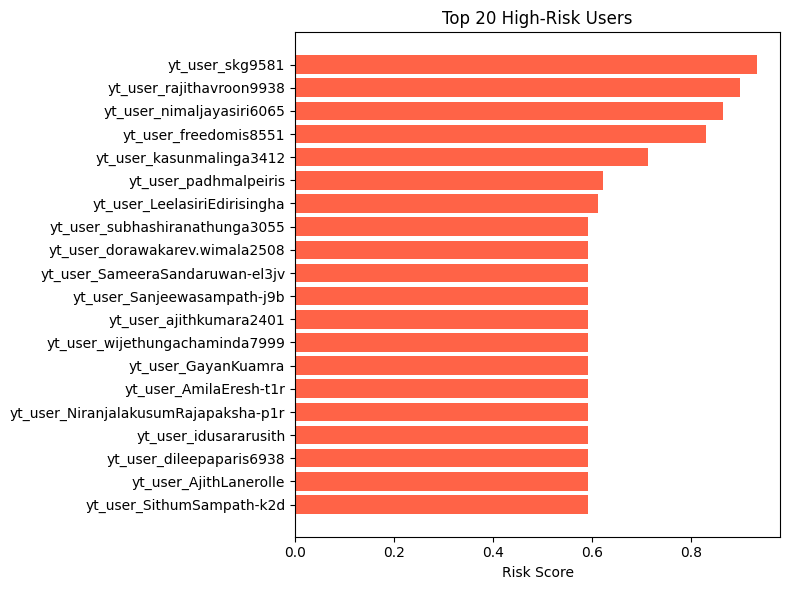

In [ ]:
top20 = user_risk_df.head(20)

plt.figure(figsize=(8, 6))
plt.barh(range(len(top20)), top20['risk_score'], color='tomato')
plt.yticks(range(len(top20)), top20.index)
plt.xlabel('Risk Score')
plt.title('Top 20 High-Risk Users')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

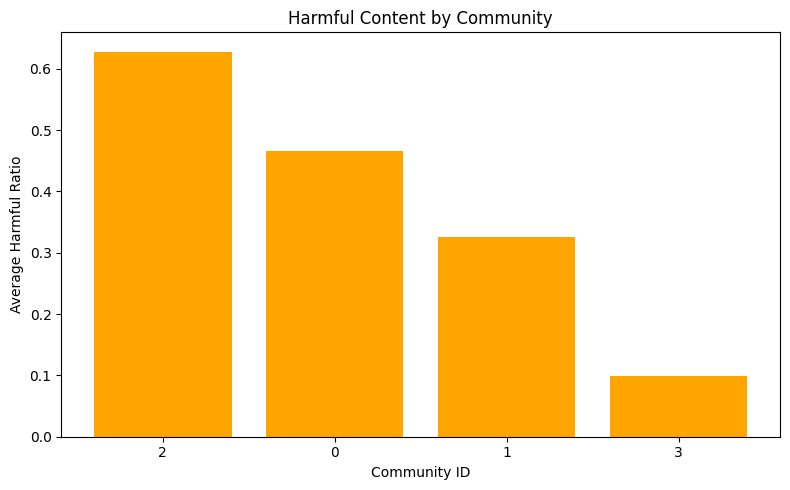

In [ ]:
# Use community_summary from earlier
plot_df = community_summary.sort_values('harmful_ratio', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df.index.astype(str), plot_df['harmful_ratio'], color='orange')
plt.xlabel('Community ID')
plt.ylabel('Average Harmful Ratio')
plt.title('Harmful Content by Community')
plt.tight_layout()
plt.show()

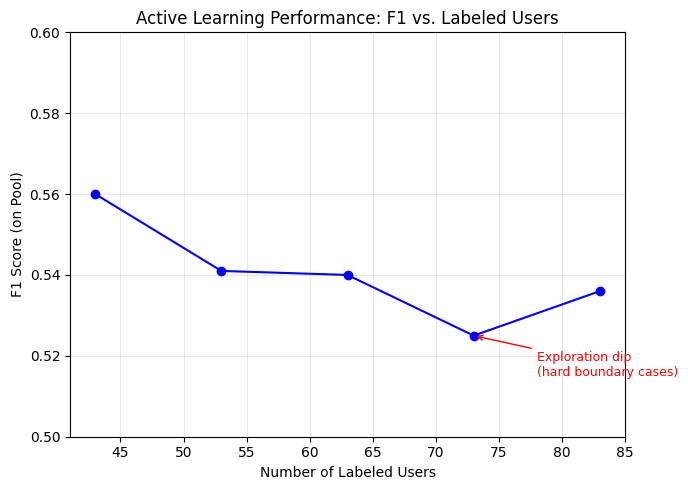

In [ ]:

# Manually enter your results from the loop
training_sizes = [43, 53, 63, 73, 83]
f1_scores = [0.560, 0.541, 0.540, 0.525, 0.536]

plt.figure(figsize=(7, 5))
plt.plot(training_sizes, f1_scores, marker='o', linestyle='-', color='blue')

# Labels and title
plt.xlabel('Number of Labeled Users')
plt.ylabel('F1 Score (on Pool)')
plt.title('Active Learning Performance: F1 vs. Labeled Users')

# Optional: y-axis limits to highlight fluctuations
plt.ylim(0.5, 0.6)

# Grid and annotation for the dip
plt.grid(alpha=0.3)
min_idx = f1_scores.index(min(f1_scores))
plt.annotate(
    'Exploration dip\n(hard boundary cases)',
    xy=(training_sizes[min_idx], f1_scores[min_idx]),
    xytext=(training_sizes[min_idx] + 5, f1_scores[min_idx] - 0.01),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9,
    color='red'
)

plt.tight_layout()
plt.show()

# Evaulation and Validation


In [ ]:

# Final model after AL
final_model = model          # from last AL round
X_test = current_X_pool      # remaining pool as test
y_test = current_y_pool

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0      0.782     0.881     0.829       236
           1      0.650     0.473     0.547       110

    accuracy                          0.751       346
   macro avg      0.716     0.677     0.688       346
weighted avg      0.740     0.751     0.739       346

[[208  28]
 [ 58  52]]


In [ ]:
def precision_at_k(df, k):
    topk = df.sort_values('risk_score', ascending=False).head(k)
    return topk['is_high_risk'].mean()

for k in [10, 20, 50, 100]:
    p_at_k = precision_at_k(influence_df, k)
    print(f"Precision@{k}: {p_at_k:.3f}")

Precision@10: 0.900
Precision@20: 0.950
Precision@50: 0.980
Precision@100: 0.990


In [ ]:
# Copy original high-risk labels
y_orig = influence_df['is_high_risk'].copy()

# Flip 10% of labels at random
np.random.seed(42)
flip_mask = np.random.rand(len(y_orig)) < 0.1
y_noisy = y_orig.copy()
y_noisy[flip_mask] = 1 - y_noisy[flip_mask]

# Correlation between original and noisy labels
from sklearn.metrics import cohen_kappa_score
print("Cohen kappa (orig vs noisy labels):", cohen_kappa_score(y_orig, y_noisy))

Cohen kappa (orig vs noisy labels): 0.725609409625547


In [ ]:
# For each user, find earliest harmful interaction time
harm = interactions_df[interactions_df['label'].isin(['Hate','Disinfo'])].copy()
first_harm = harm.groupby('user_id')['timestamp'].min().rename('first_harm_ts')

# Merge into influence_df
influence_df = influence_df.join(first_harm, how='left')

# Early vs late harmful users
median_ts = influence_df['first_harm_ts'].dropna().median()
early = influence_df[influence_df['first_harm_ts'] <= median_ts]
late = influence_df[influence_df['first_harm_ts'] > median_ts]

print("Mean risk_score (early harmful users):", early['risk_score'].mean())
print("Mean risk_score (late harmful users):", late['risk_score'].mean())

Mean risk_score (early harmful users): 0.5314711104287869
Mean risk_score (late harmful users): 0.5262053470999029


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0      0.782     0.881     0.829       236
           1      0.650     0.473     0.547       110

    accuracy                          0.751       346
   macro avg      0.716     0.677     0.688       346
weighted avg      0.740     0.751     0.739       346



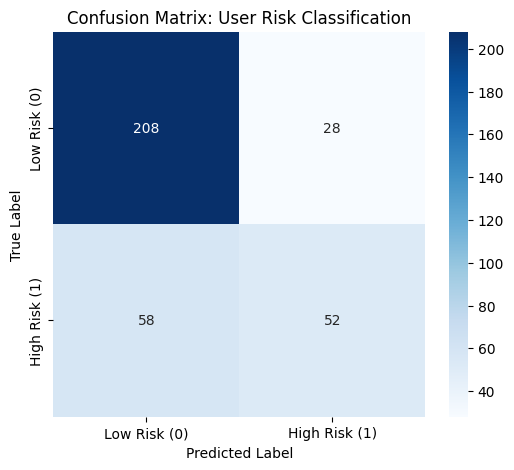

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict on remaining pool using the final active learning model
y_pred_final = model.predict(current_X_pool)

# 2. Print detailed text report
print("--- Classification Report (Test Set) ---")
print(classification_report(current_y_pool, y_pred_final, digits=3))

# 3. Plot Confusion Matrix
cm = confusion_matrix(current_y_pool, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk (0)', 'High Risk (1)'],
            yticklabels=['Low Risk (0)', 'High Risk (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: User Risk Classification')
plt.show()

In [ ]:
# Ground truth high-risk label already in influence_df['is_high_risk']
# risk_score already computed in influence_df

def precision_at_k(df, k):
    topk = df.sort_values('risk_score', ascending=False).head(k)
    return topk['is_high_risk'].mean()

for k in [10, 20, 50, 100]:
    p_at_k = precision_at_k(influence_df, k)
    print(f"Precision@{k}: {p_at_k:.3f}")

Precision@10: 0.900
Precision@20: 0.950
Precision@50: 0.980
Precision@100: 0.990


Final Step to save stuff in Git



In [ ]:
!git config --global user.email "theo.hfern@gmail.com"
!git config --global user.name "Thiyasha0315"

In [ ]:
!git status
!git add .
!git commit -m "Add the Bipartite Graphs"
!git push

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [ ]:
#Merge to main and switch back
!git checkout main
!git pull origin main
!git checkout thiyasha-dev

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
